# data kagle: 
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=CAR+DETAILS+FROM+CAR+DEKHO.csv

In [49]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

# Data collecction ,processing 

In [50]:
df=pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# data clining 

In [ ]:
df.Seller_Type.value_counts()
df.Fuel_Type.value_counts()
df.Transmission.value_counts()
df["Fuel_Type"] = df["Fuel_Type"].replace({"Diesel": 1, "Petrol": 2, "CNG": 3})
df["Transmission"]=df["Transmission"].replace({"Manual":1,"Automatic":2}).astype(int)
df['Seller_Type']=df["Seller_Type"].replace({"Dealer":1,"Individual":2}).astype(int)


df.info()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    int64  
 7   Transmission   301 non-null    int64  
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(5), object(1), str(1)
memory usage: 21.3+ KB


np.int64(2)

In [52]:
df.describe() 

,Year,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,1.352159,1.132890,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.478439,0.340021,0.247915
min,2003.000000,0.100000,0.320000,500.000000,1.000000,1.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,1.000000,1.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,1.000000,1.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,2.000000,1.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,2.000000,2.000000,3.000000


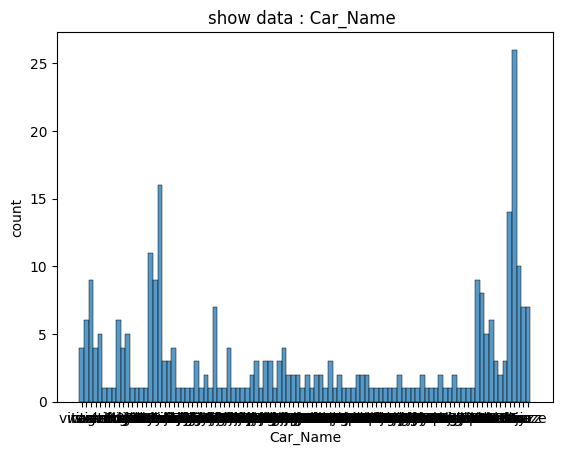

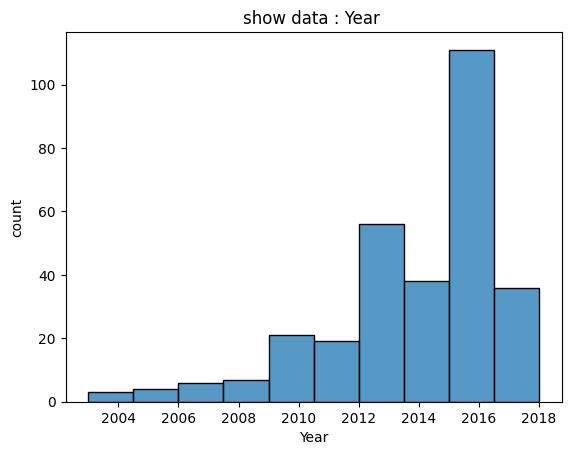

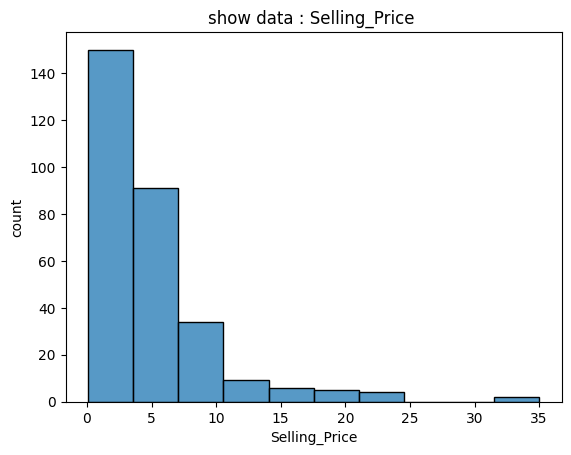

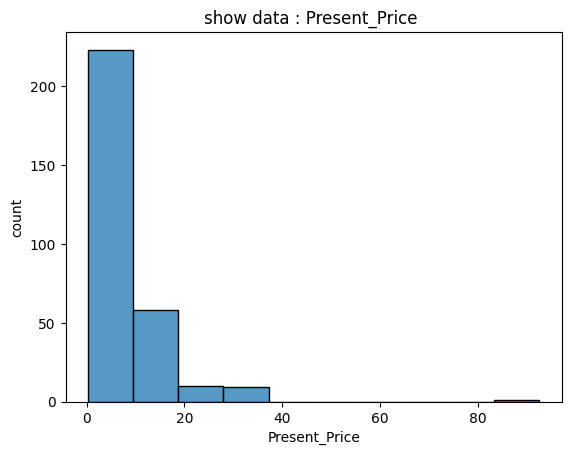

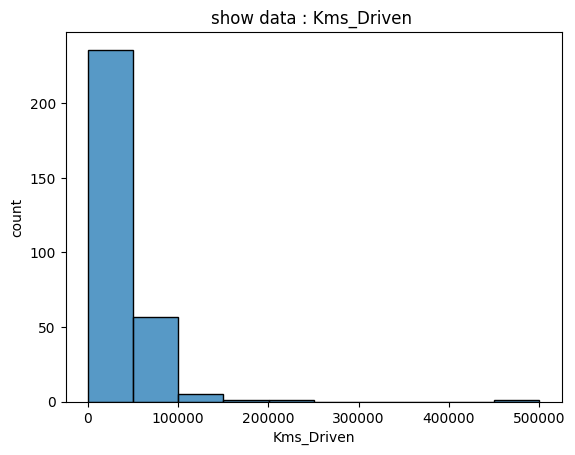

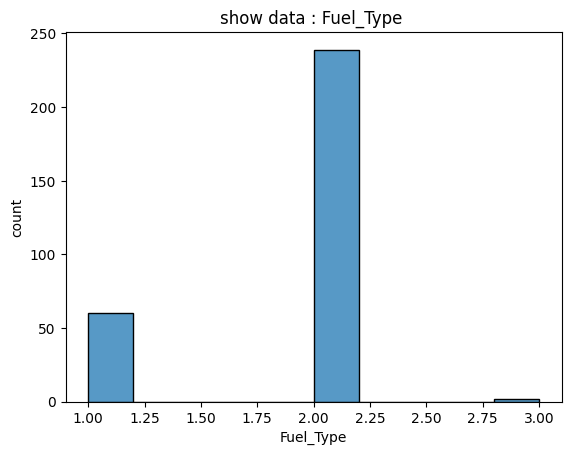

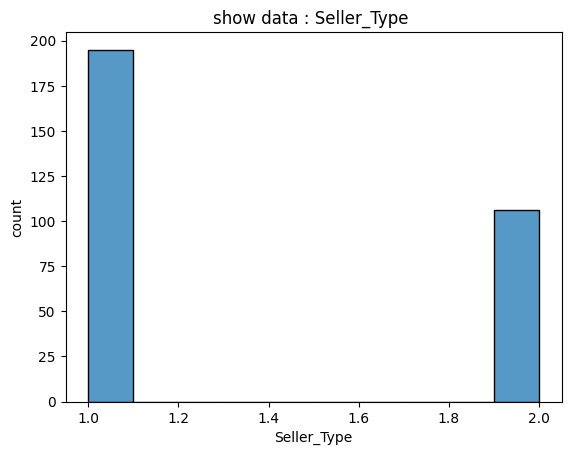

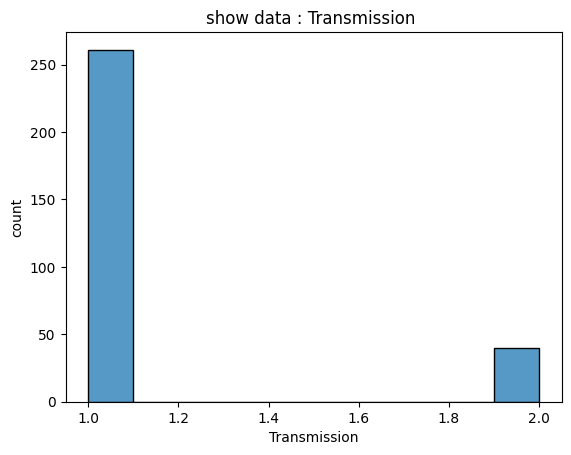

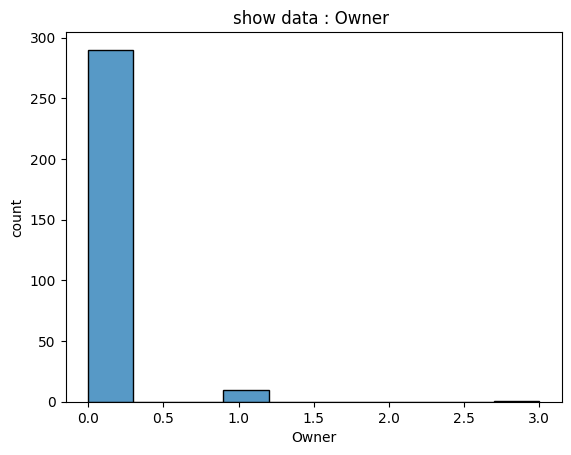

In [53]:
import seaborn as sns 
df.columns
columns=['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
for col in columns:
    sns.histplot(x=df[col],bins=10)
    plt.title(f"show data : {col} ")
    plt.xlabel(f"{col}")
    plt.ylabel(f"count")
    plt.show()

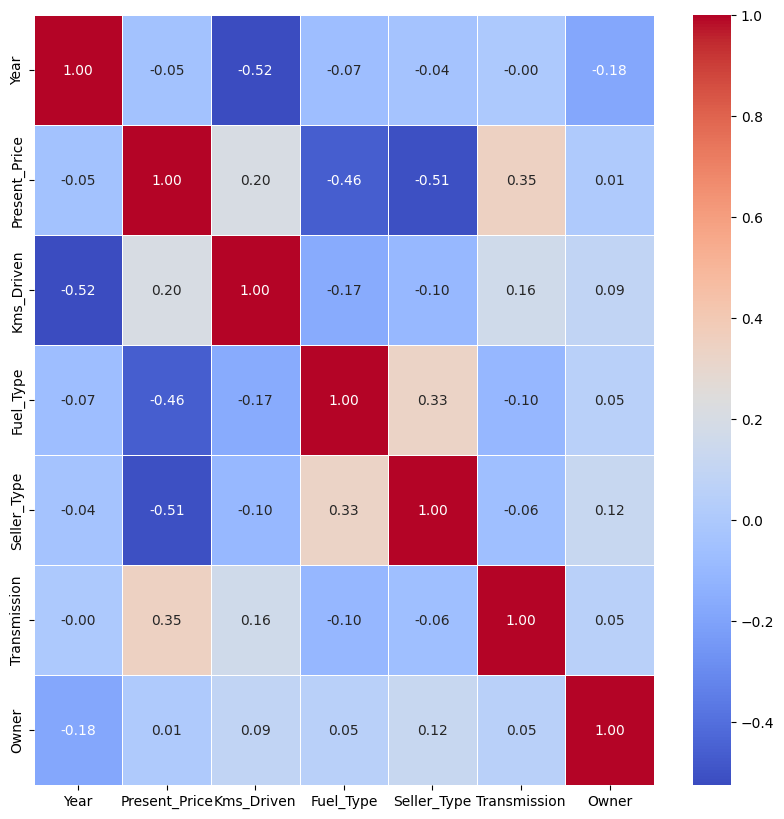

In [ ]:
corr= x.corr()
plt.figure(figsize=(10, 10))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.show()

# traing test data 
تقسم البيانات لي تدريب و اختبار 

In [55]:

x=df[['Year', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']]
y=df['Selling_Price']

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

# creat model 
انشاء النموزج


In [57]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


# training from data 

In [58]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# predication of traing data 
التنبوا من خلال قيم التديرب 

In [59]:
y_Tarin_pred=model.predict(x_train)

In [60]:
from sklearn import metrics
R2=metrics.r2_score(y_Tarin_pred,y_train)
mes=metrics.mean_absolute_error(y_Tarin_pred,y_train)

In [ ]:
print(f"mean_absolute_error: f{mes}")
print(f"R2_score : {R2}")

0.8700001569950202

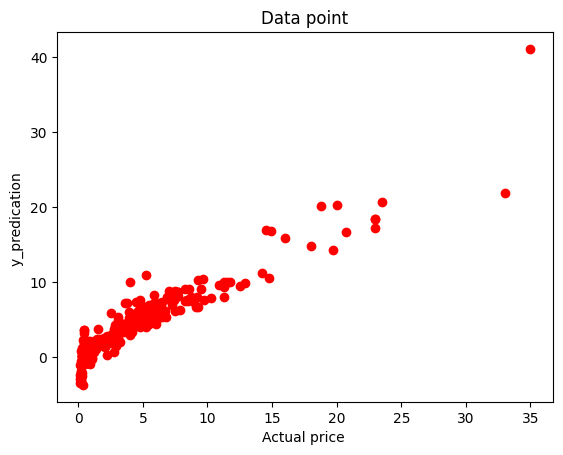

In [62]:
plt.scatter(y_train,y_Tarin_pred,color='r',marker='o')
plt.title("Data point")
plt.xlabel("Actual price ")
plt.ylabel("y_predication ")
plt.show()

In [63]:
y_test_predcted=model.predict(x_test)

In [ ]:
y_test_predcted

array([ 3.1004162 ,  8.17704407,  6.41413817, -1.42122493,  8.9420375 ,
        7.51020199,  1.39989616,  0.87905711,  1.47796948,  7.53996827,
        9.35886425,  0.56514273,  8.37386452,  3.62535432,  6.91133089,
        2.89581572,  0.44119671, 10.74447066,  1.90853319,  2.50669983,
        0.39396855,  8.26802696,  6.60623796,  2.46154904,  0.80817872,
        3.52142512,  5.09583596,  2.61027663,  2.29017378,  1.86135355,
        0.39061826])

In [65]:
R2score=metrics.r2_score(y_test_predcted,y_test)
mean_sqeared_error=metrics.mean_absolute_error(y_test_predcted,y_test)

In [66]:
R2score

0.7564186451684352

In [67]:
mean_sqeared_error

1.0404333468454612

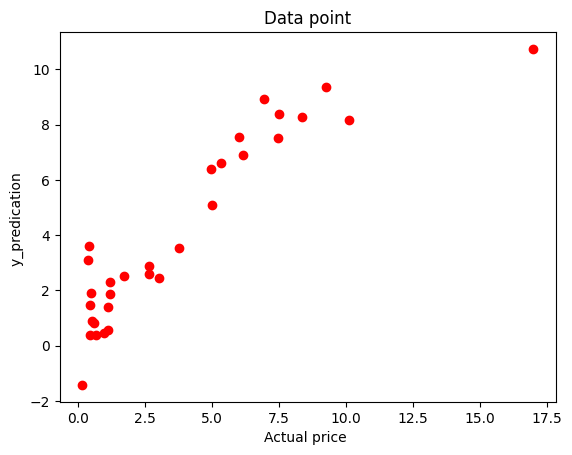

In [68]:
plt.scatter(y_test,y_test_predcted,color='r',marker='o')
plt.title("Data point")
plt.xlabel("Actual price ")
plt.ylabel("y_predication ")
plt.show()

# creat linear less 
الانحدار الاسواء
التعديل في  

In [69]:
from sklearn.linear_model import Lasso
model_lasso=Lasso()


In [70]:
model_lasso.fit(x_train,y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [71]:
y_train_predict_lasso = model_lasso.predict(x_train)


In [72]:
R2score_lesso=metrics.r2_score(y_train_predict_lasso,y_train)
mes_less=metrics.mean_absolute_error(y_train_predict_lasso,y_train)
print("R2score_lesso : ",R2score_lesso)
print(f"mean sqared error lesso  {mes_less}")

R2score_lesso :  0.7998618265707464
mean sqared error lesso  1.2808573018471214


In [73]:
model_lasso.fit(x_test,y_test)
y_test_predct_lesso=model_lasso.predict(x_test)


In [74]:
R2score_test_lesso=metrics.r2_score(y_test_predct_lesso,y_test)
mes_test_less=metrics.mean_absolute_error(y_test_predct_lesso,y_test)
print("R2score_lesso : ",R2score_test_lesso)
print(f"mean sqared error lesso  {mes_test_less}")

R2score_lesso :  0.841920670822065
mean sqared error lesso  0.8587635287448083


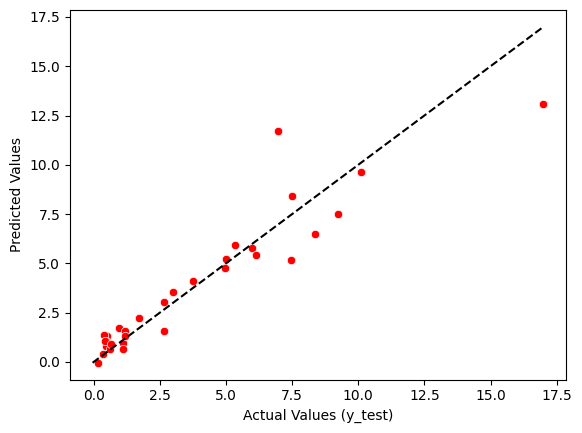

In [ ]:
sns.scatterplot(x=y_test, y=y_test_predct_lesso, color='r')


lw_bound = min(y_test.min(), y_test_predct_lesso.min())
he_bound = max(y_test.max(), y_test_predct_lesso.max())

# 3. رسم خط التطابق المثالي
plt.plot([lw_bound, he_bound], [lw_bound, he_bound], color='black', linestyle='--')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')
plt.show()

In [76]:
w=model_lasso.coef_
b=model_lasso.intercept_

In [77]:
print(f"weight : {w}")
print(f"baise : {b}")
w.shape

weight : [ 0.00000000e+00  6.64334326e-01 -4.24350542e-05 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00]
baise : 1.065675077663693


(7,)

In [ ]:
year = int(input("Year: "))
present = float(input("Present_Price: "))  
Kms_Driven = int(input("Kms_Driven: "))
Fuel_Type = int(input("Fuel_Type: "))
Seller_Type = int(input("Seller_Type: "))
Transmission = int(input("Transmission: "))
Owner = int(input("Owner: "))


New_input_data = [year, present, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner]
New_input_data =np.array(New_input_data)



 

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Car_Name</th>
      <th>Year</th>
      <th>Selling_Price</th>
      <th>Present_Price</th>
      <th>Kms_Driven</th>
      <th>Fuel_Type</th>
      <th>Seller_Type</th>
      <th>Transmission</th>
      <th>Owner</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>ritz</td>
      <td>2014</td>
      <td>3.35</td>
      <td>5.59</td>
      <td>27000</td>
      <td>2</td>
      <td>1</td>
      <td>1</td>
      <td>0</td>
    </tr>
  </tbody>
</table>
</div>

In [ ]:
ypredctios = np.sum(New_input_data * w) + b

print(f"ypredctios: {ypredctios}")

ypredctios: 13.051501457377745
